# Spatial Econometrics — Two Case Studies

**Companion to deck `05-spatial-dependence` (Part 3 — Spatial model structure).**

Spatial econometrics embeds spatial dependence in the regression itself. This notebook
runs the **same three-move workflow — detect → diagnose → model — on two classic
literature datasets that reach *opposite* verdicts**, so the point is not a recipe but a
decision rule:

- **Part A — Regional income in Mexico** (Rey & Sastre-Gutiérrez, 2010): the *convergence*
  question on the 32 states. Here, once the 1940 starting level is controlled, the residuals
  are clean — **OLS is enough**.
- **Part B — Crime in Columbus, Ohio** (Anselin, 1988, the founding example): the residual
  diagnostics demand a spatial model, and we fit and interpret one — **a spatial lag (SAR)**.

The three moves:

1. **Detect** dependence — global Moran'''s I and LISA on the outcome.
2. **Diagnose** — fit OLS with spatial diagnostics; let the residuals decide the model.
3. **Decide & interpret** — fit the indicated spatial model and read its direct/indirect/total
   impacts.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import esda
import spreg
from libpysal.graph import Graph
from splot.esda import lisa_cluster

%config InlineBackend.figure_format = "retina"

SEED = 42   # fixed seed -> reproducible permutation p-values

## The data

Each polygon is a state. Key columns:

- **`LPCGDP00`** — log per-capita GDP in 2000 (the outcome).
- **`LPCGDP40`** — log per-capita GDP in 1940 (the starting level; convergence predictor).
- **`MAXP`** — a categorical regional indicator (decade of peak growth, 1–5).

The shapefile ships without a `.prj`, so we assign the CRS explicitly.

In [2]:
gdf = gpd.read_file("data/mexico/mexicojoin.shp").set_crs(4326)
print(f"{len(gdf)} states, CRS {gdf.crs.to_epsg()}")
gdf[["NAME", "LPCGDP40", "LPCGDP00", "MAXP"]].head()

32 states, CRS 4326


,NAME,LPCGDP40,LPCGDP00,MAXP
0,Baja California Norte,4.35,4.48,2.0
1,Baja California Sur,3.98,4.42,2.0
2,Nayarit,3.68,4.06,1.0
3,Jalisco,3.73,4.33,4.0
4,Aguascalientes,4.02,4.44,4.0


## 1. Detecting spatial dependence

Build a **Queen** contiguity graph and run global Moran's I and LISA *directly on the
`Graph`* — `esda` accepts either the modern `Graph` or a legacy `W`.

In [3]:
g = Graph.build_contiguity(gdf, rook=False)          # Queen contiguity
print("isolates:", len(g.isolates), " components:", g.n_components)

np.random.seed(SEED)
mi   = esda.Moran(gdf["LPCGDP00"], g, permutations=999)        # global
lisa = esda.Moran_Local(gdf["LPCGDP00"], g, permutations=999, seed=SEED)  # local

print(f"Global Moran's I = {round(mi.I, 2)},  p_sim = {mi.p_sim}")
print(f"LISA significant areas (p < 0.05): {int((lisa.p_sim < 0.05).sum())}")

isolates: 0  components: 1


Global Moran's I = 0.26,  p_sim = 0.01
LISA significant areas (p < 0.05): 6


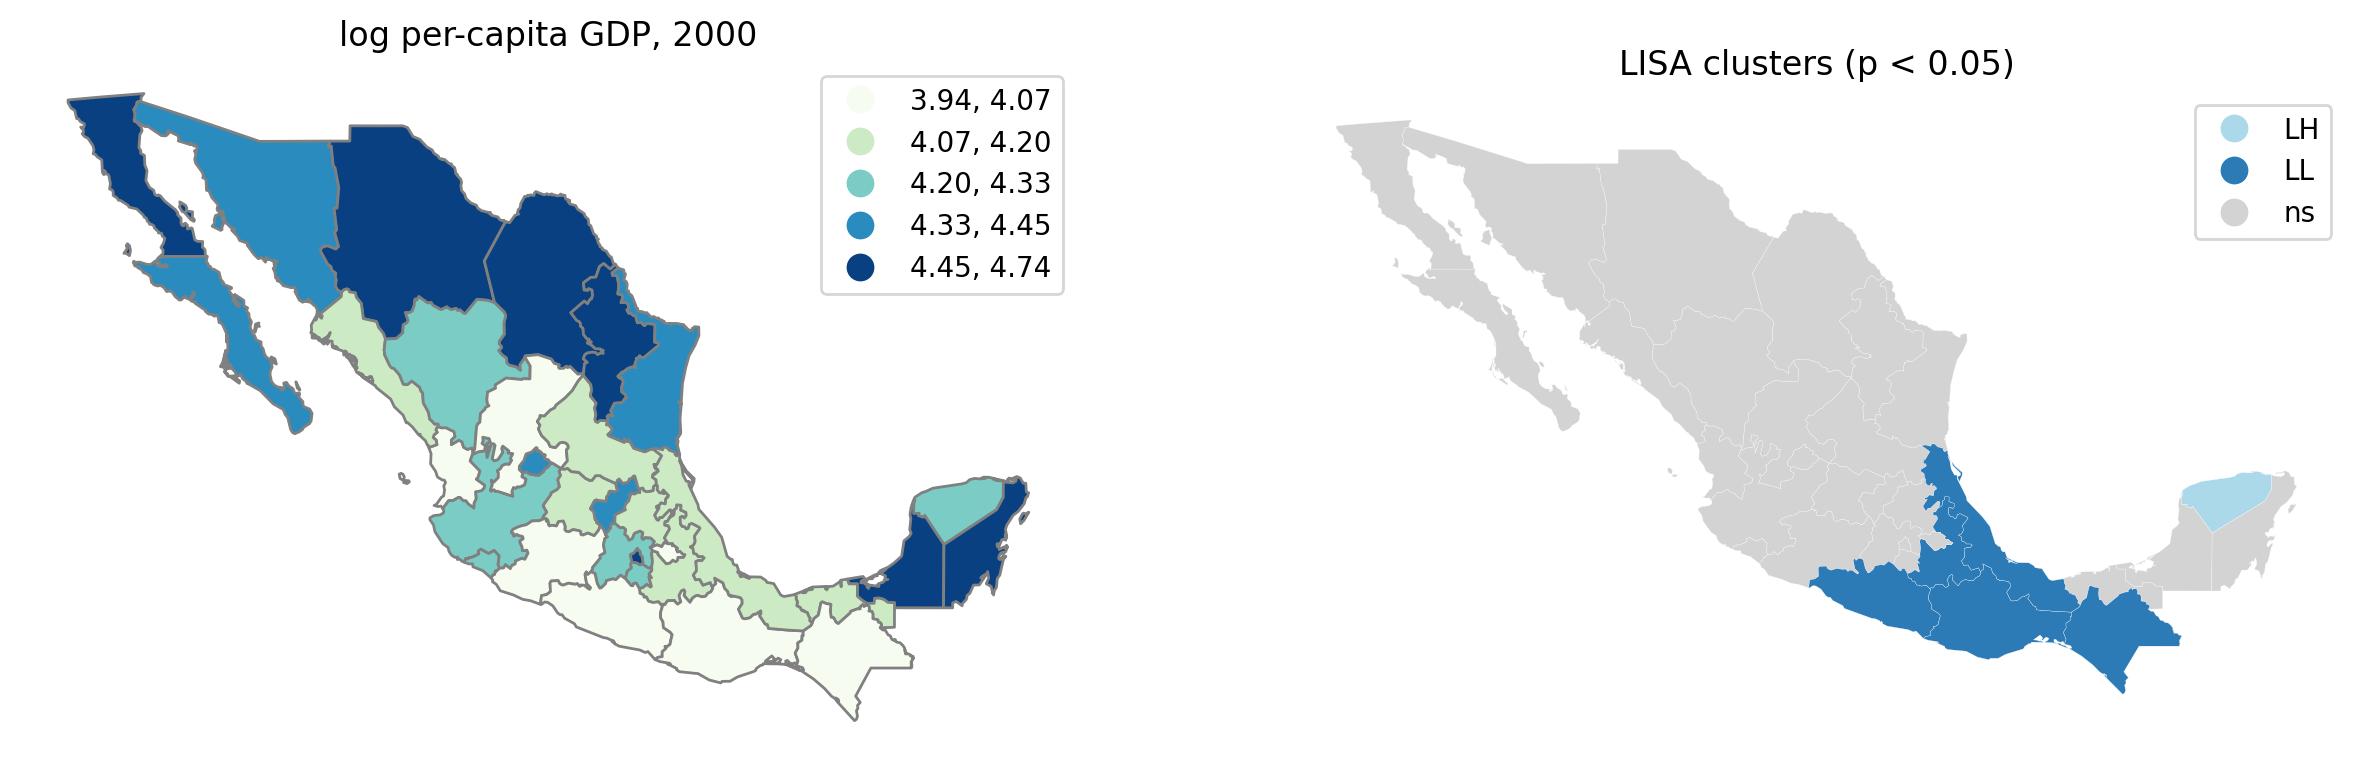

In [4]:
f, ax = plt.subplots(1, 2, figsize=(15, 6))
gdf.plot(column="LPCGDP00", scheme="quantiles", k=5, cmap="GnBu",
         edgecolor="grey", legend=True, ax=ax[0])
ax[0].set_title("log per-capita GDP, 2000")
lisa_cluster(lisa, gdf, p=0.05, ax=ax[1])
ax[1].set_title("LISA clusters (p < 0.05)")
for a in ax:
    a.set_axis_off()
plt.show()

- Global Moran's I `= 0.26`, `p_sim = 0.01` → **incomes cluster** (positive
  autocorrelation).
- LISA flags **6 significant areas** — a southern **low–low** cluster of poor states
  (Oaxaca, Guerrero, Chiapas, Puebla, Veracruz) ringed by poor states.

**Lesson —** a significant global I earns you the right to model space, but LISA shows
the pattern is *regional*, not global — the "where" guides the specification.

## Model families (the menu)

Spatial econometrics embeds dependence in the equation itself. The main families
differ in *where* the spatial term sits (Anselin, 1988):

- **SLX**: $Y = X\beta + WX\theta + \varepsilon$ — local exogenous spillovers (OLS-estimable).
- **SAR** (lag): $Y = \rho WY + X\beta + \varepsilon$ — global endogenous feedback.
- **SEM** (error): $Y = X\beta + u,\; u = \lambda Wu + \varepsilon$ — spatially correlated shocks.
- **SDM**: SAR + SLX;  **SDEM**: SEM + SLX;  **SAC/SARAR**: SAR + SEM.

Which one? Don't pick by taste — let the OLS residual diagnostics point the way.

## 2. OLS with spatial diagnostics

Bridge the modern `Graph` to the legacy row-standardised `W` that `spreg` expects,
then fit OLS with spatial diagnostics turned on. The read-out decides whether the OLS
residuals are clean or a lag/error model is warranted.

In [5]:
w = g.to_W(); w.transform = "r"          # bridge: row-standardized W
y = gdf[["LPCGDP00"]].values
X = gdf[["LPCGDP40", "MAXP"]].values

np.random.seed(SEED)
ols = spreg.OLS(y, X, w=w, spat_diag=True, moran=True,
                name_y="LPCGDP00", name_x=["LPCGDP40", "MAXP"])

diag = pd.DataFrame(
    {"statistic": [ols.moran_res[0], ols.lm_lag[0], ols.rlm_lag[0],
                   ols.lm_error[0], ols.rlm_error[0]],
     "p-value":   [ols.moran_res[2], ols.lm_lag[1], ols.rlm_lag[1],
                   ols.lm_error[1], ols.rlm_error[1]]},
    index=["Moran's I (residuals)", "LM-lag", "robust LM-lag",
           "LM-error", "robust LM-error"]).round(2)
diag

,statistic,p-value
Moran's I (residuals),-0.05,0.95
LM-lag,0.58,0.45
robust LM-lag,2.56,0.11
LM-error,0.14,0.71
robust LM-error,2.12,0.15


**Reading:** the raw outcome clusters, but once 1940 income (itself spatially
patterned) is controlled the **residual Moran's I is −0.05, p = 0.95** — the residuals
are clean, so OLS is defensible here. The robust LM tests only *hint* at a lag; with
`n = 32` power is low.

**Lesson —** let the diagnostics pick the model: a clean residual Moran's I says OLS is
enough — don't fit a spatial model reflexively.

## 3. Spatial lag model & impacts

For illustration we still fit the spatial lag model by **IV / 2SLS** (`GM_Lag`) and
read its impact decomposition. Once an outcome lag $\rho WY$ enters, the raw
coefficients are no longer the effects: a change in one state ripples through
neighbours via the spatial multiplier $(I-\rho W)^{-1}$ and loops back. We therefore
report **direct**, **indirect** (spillover), and **total** impacts.

In [6]:
np.random.seed(SEED)
gm = spreg.GM_Lag(y, X, w=w, spat_impacts="all",
                  name_y="LPCGDP00", name_x=["LPCGDP40", "MAXP"])

rho = gm.betas[-1, 0]
print(f"rho (spatial autoregressive parameter) = {rho:.2f}")
print("spatial multipliers (direct, indirect, total):",
      tuple(round(m, 2) for m in gm.sp_multipliers["simple"]))

rho (spatial autoregressive parameter) = 0.55
spatial multipliers (direct, indirect, total): (1.0, 1.23, 2.23)


In [7]:
# Compact direct/indirect/total impacts for the two covariates
betas = gm.betas.flatten()                 # [const, LPCGDP40, MAXP, rho]
md_, mi_, mt_ = gm.sp_multipliers["simple"]
impacts = pd.DataFrame(
    {"Direct":   betas[1:3] * md_,
     "Indirect": betas[1:3] * mi_,
     "Total":    betas[1:3] * mt_},
    index=["LPCGDP40", "MAXP"]).round(2)
impacts

,Direct,Indirect,Total
LPCGDP40,0.43,0.52,0.95
MAXP,0.03,0.04,0.07


With $\rho \approx 0.55$ the multiplier splits each coefficient into a **direct**
and a comparable **indirect** part. A one-unit rise in a state's own 1940 log-income is
associated with **0.43** direct increase and **0.52** indirect increase through
neighbour feedback, for a **0.95** total effect.

**Lesson —** whenever $\rho \neq 0$, report impacts, not raw coefficients: the
spillover (indirect) piece here is as large as the own-area (direct) effect.

## Recap

1. **Detect** — global Moran's I = 0.26 (p = 0.01); LISA isolates a southern low–low cluster.
2. **Diagnose** — OLS residual Moran's I = −0.05 (p = 0.95): OLS is defensible; controlling
   for 1940 income absorbs the spatial pattern.
3. **Interpret** — had a lag been warranted ($\rho \approx 0.55$), the report is
   direct / indirect / total impacts, not bare $\beta$.

> References: Anselin (1988); Rey & Sastre-Gutiérrez (2010); Anselin & Rey (2014),
> *Modern Spatial Econometrics in Practice*; `spreg` documentation.

---

# Part B — the whole model family on one dataset: Columbus crime (Anselin, 1988)

The Mexico case ended at "OLS is enough." Here is the **founding dataset of spatial
econometrics** (Anselin, 1988, *Spatial Econometrics: Methods and Models*), where the
diagnostics demand a spatial model — so we can fit and **compare the whole family** on one
real, well-studied example.

**Setting.** 49 planning neighbourhoods of **Columbus, Ohio**:

- **`CRIME`** — residential burglaries + vehicle thefts per 1,000 households (outcome),
- **`INC`** — household income (\$1,000s),
- **`HOVAL`** — housing value (\$1,000s).

## The taxonomy — three kinds of spatial effect

A spatial regression can carry up to **three** distinct spatial terms (LeSage & Pace, 2009;
Elhorst, 2014). *Which* terms you switch on names the model:

- **Endogenous interaction — $\rho\,WY$:** a neighbour's **outcome** affects mine. The
  feedback is *global* — a shock in one place loops through the entire system via the
  multiplier $(I-\rho W)^{-1}$. → **SAR (lag)**.
- **Exogenous interaction — $WX\theta$:** a neighbour's **covariate** affects my outcome. The
  spillover is *local* (one step over the graph) and stays **OLS-estimable**. → **SLX**.
- **Error dependence — $\lambda\,Wu$:** spatially correlated **shocks** — the sign of an
  omitted spatial variable. A *nuisance*: it fixes inference but carries **no spillover to
  interpret**. → **SEM (error)**.

| Model | $\rho WY$ (endogenous) | $WX\theta$ (exogenous) | $\lambda Wu$ (error) |
|---|:---:|:---:|:---:|
| **OLS** | – | – | – |
| **SLX** | – | ✓ | – |
| **SAR** (lag) | ✓ | – | – |
| **SEM** (error) | – | – | ✓ |
| **SDM** (Durbin) | ✓ | ✓ | – |
| **SDEM** | – | ✓ | ✓ |
| **SAC / SARAR** | ✓ | – | ✓ |

We fit the five boldface rows and let the data choose.

In [8]:
from libpysal.examples import load_example

col = gpd.read_file(load_example("Columbus").get_path("columbus.shp"))
print(f"{len(col)} neighbourhoods")
col[["CRIME", "INC", "HOVAL"]].describe().round(1)

49 neighbourhoods


,CRIME,INC,HOVAL
count,49.0,49.0,49.0
mean,35.1,14.4,38.4
std,16.7,5.7,18.5
min,0.2,4.5,17.9
25%,20.0,10.0,25.7
50%,34.0,13.4,33.5
75%,48.6,18.3,43.3
max,68.9,31.1,96.4


## 1. Detect & diagnose — does OLS survive?

Build a **Queen** contiguity graph, bridge it to the row-standardised `W` `spreg` expects,
and fit OLS with the spatial diagnostics on. The residual read-out decides whether OLS is
defensible and, if not, *which* spatial term is missing.

In [9]:
gc = Graph.build_contiguity(col, rook=False)     # Queen contiguity
wc = gc.to_W(); wc.transform = "r"               # row-standardised W

yc = col[["CRIME"]].values
Xc = col[["INC", "HOVAL"]].values

np.random.seed(SEED)
ols_c = spreg.OLS(yc, Xc, w=wc, spat_diag=True, moran=True,
                  name_y="CRIME", name_x=["INC", "HOVAL"])

diag_c = pd.DataFrame(
    {"statistic": [ols_c.moran_res[0], ols_c.lm_lag[0], ols_c.rlm_lag[0],
                   ols_c.lm_error[0], ols_c.rlm_error[0]],
     "p-value":   [ols_c.moran_res[2], ols_c.lm_lag[1], ols_c.rlm_lag[1],
                   ols_c.lm_error[1], ols_c.rlm_error[1]]},
    index=["Moran's I (residuals)", "LM-lag", "robust LM-lag",
           "LM-error", "robust LM-error"]).round(4)
print(f"OLS R-squared = {ols_c.r2:.3f}")
diag_c

OLS R-squared = 0.552


,statistic,p-value
Moran's I (residuals),0.2221,0.0045
LM-lag,8.8980,0.0029
robust LM-lag,3.7357,0.0533
LM-error,5.2062,0.0225
robust LM-error,0.0439,0.8340


**Reading (contrast with Mexico).** The **residual Moran's I = 0.22, p = 0.004** — OLS
residuals are *strongly* spatially dependent, so OLS is **not** defensible here: standard
errors are wrong and, if a lag is present, the coefficients are biased.

**Which term is missing?** Both `LM-lag` and `LM-error` are significant, so apply Anselin's
decision rule — read the **robust** versions (each controls for the other):

- robust **LM-lag** → *p* ≈ 0.05 (significant)
- robust **LM-error** → *p* ≈ 0.83 (not)

The diagnostics point to the **endogenous lag** ($\rho WY$), not the error term.

**Lesson —** the same OLS diagnostics that vindicated OLS in Mexico here reject it *and* name
the culprit: significant residual Moran's I + robust LM-lag ⇒ fit a spatial **lag** model.

## 2. Fit the family, choose by AIC

Fit **OLS, SLX, SAR, SEM, SDM** by maximum likelihood and rank them by **AIC** (lower is
better; AIC rewards fit but penalises each extra parameter, so it will not reward a bigger
model unless the data earn it). `slx_lags=1` adds the exogenous $WX$ block.

In [10]:
models = {
    "OLS": spreg.OLS   (yc, Xc, w=wc,               name_y="CRIME", name_x=["INC", "HOVAL"]),
    "SLX": spreg.OLS   (yc, Xc, w=wc, slx_lags=1,   name_y="CRIME", name_x=["INC", "HOVAL"]),
    "SAR": spreg.ML_Lag(yc, Xc, w=wc,               name_y="CRIME", name_x=["INC", "HOVAL"]),
    "SEM": spreg.ML_Error(yc, Xc, w=wc,             name_y="CRIME", name_x=["INC", "HOVAL"]),
    "SDM": spreg.ML_Lag(yc, Xc, w=wc, slx_lags=1,   name_y="CRIME", name_x=["INC", "HOVAL"]),
}
terms = {"OLS": "—", "SLX": "WX (exog.)", "SAR": "rho*WY (endog.)",
         "SEM": "lambda*Wu (error)", "SDM": "rho*WY + WX (both)"}

ladder = (pd.DataFrame(
    [{"model": k, "spatial terms": terms[k],
      "logL": round(m.logll, 1), "AIC": round(m.aic, 1)} for k, m in models.items()])
    .set_index("model").sort_values("AIC"))
ladder

,spatial terms,logL,AIC
model,,,
SAR,rho*WY (endog.),-182.7,373.3
SEM,lambda*Wu (error),-183.7,373.5
SDM,rho*WY + WX (both),-181.6,375.3
SLX,WX (exog.),-184.0,377.9
OLS,—,-187.4,380.8


**Reading the ladder.**

- **SAR has the lowest AIC (≈ 373.3)** → the family selects the endogenous lag — exactly what
  the robust LM test flagged. Diagnostics and model selection agree.
- **SLX (≈ 377.9) already beats OLS (≈ 380.8)**: even a purely *exogenous* neighbour effect
  ($WX$, OLS-estimable) improves the fit — space matters even before any feedback.
- **SEM (≈ 373.5) ≈ SAR** on AIC, but both the robust LM and the (marginally) lower SAR AIC
  favour lag over error.
- **SDM has the best raw log-likelihood** (it nests SAR *and* SLX) but a *higher* AIC — its two
  extra $WX$ parameters are not worth their penalty here.

**Lesson —** don't pick a spatial model by taste: fit the family and let AIC (agreeing with the
LM diagnostics) choose. Here every route points to **SAR**.

## 3. Interpret — the impacts, step by step

The spatial term changes *what a coefficient means*. Two cases:

- **SLX (exogenous):** the neighbour term $WX$ **is** the spillover — read it straight off
  (`W_INC` = effect of *neighbours'* income on local crime). No decomposition needed.
- **SAR (endogenous):** because $Y$ feeds back on $WY$, the raw $\beta$ is **not** the effect.
  We must decompose it into **direct / indirect / total** impacts — the rest of this section.

### The spatial multiplier — where the impacts come from

Solve the SAR model for $Y$:

$$Y=\rho WY+X\beta+\varepsilon \;\Longrightarrow\; Y=(I-\rho W)^{-1}(X\beta+\varepsilon).$$

The matrix $M=(I-\rho W)^{-1}$ is the **spatial multiplier**. Expand it as a series:

$$M=I+\rho W+\rho^2 W^2+\rho^3 W^3+\cdots$$

A one-unit change in a covariate does **not** stay put: it hits the region itself ($I$), then
its neighbours ($\rho W$), then neighbours-of-neighbours ($\rho^2 W^2$), each ripple weaker
than the last (because $|\rho|<1$). So the full effect of changing covariate $x_k$ is the
**whole matrix** $S_k=\beta_k\,M$, not the scalar $\beta_k$. LeSage & Pace (2009) summarise
$S_k$ as three averages:

- **Direct** — average of the **diagonal** of $S_k$: the effect on a region's *own* outcome of
  changing its *own* $x$, **including feedback** that leaves and loops back through neighbours.
- **Indirect (spillover)** — average of the **off-diagonal row sums**: the effect on a region
  from changing $x$ in **all other** regions.
- **Total** — direct + indirect $=\beta_k/(1-\rho)$ (row-standardised $W$): the effect of
  raising $x$ **everywhere** at once.

In [11]:
# --- SLX: the exogenous spillover is a coefficient you read directly ---
slx = models["SLX"]
print("SLX - neighbours' effect is a plain coefficient (exogenous spillover):")
print(pd.DataFrame({"coef": slx.betas.flatten().round(3)}, index=slx.name_x), "\n")

# --- SAR: build the multiplier M = (I - rho W)^-1 and decompose the impacts ---
sar = models["SAR"]                                   # ML_Lag from the ladder
rho = sar.betas[-1, 0]
M   = np.linalg.inv(np.eye(wc.n) - rho * wc.full()[0])   # I + rhoW + rho^2 W^2 + ...

rows = []
for name, idx in [("INC", 1), ("HOVAL", 2)]:
    S = sar.betas[idx, 0] * M                          # dY/dx_k = beta_k * M   (n x n)
    direct = np.diag(S).mean()                         # own region (incl. feedback)
    total  = S.sum(axis=1).mean()                      # = beta_k / (1 - rho)
    rows.append({"Direct": direct, "Indirect": total - direct, "Total": total})

impacts = pd.DataFrame(rows, index=["INC", "HOVAL"]).round(2)
print(f"rho = {rho:.2f}   avg diagonal of M = {np.diag(M).mean():.2f} "
      f"(> 1: a shock loops out and partly returns)")
impacts

SLX - neighbours' effect is a plain coefficient (exogenous spillover):
            coef
CONSTANT  74.553
INC       -1.097
HOVAL     -0.294
W_INC     -1.399
W_HOVAL    0.215 

rho = 0.42   avg diagonal of M = 1.05 (> 1: a shock loops out and partly returns)


,Direct,Indirect,Total
INC,-1.10,-0.72,-1.82
HOVAL,-0.28,-0.18,-0.46


### Reading the Columbus impacts in words

Take **`INC`** — direct **−1.10**, indirect **−0.72**, total **−1.82**:

- **Direct −1.10** — raise *one* neighbourhood's own median income by \$1,000 and its *own*
  crime falls by ≈ 1.1 per 1,000 households. This already folds in the feedback that loops
  back through its neighbours — which is why $|{-1.10}|$ slightly exceeds the raw
  $\beta=-1.05$.
- **Indirect −0.72** — that *same* \$1,000 rise **also** lowers **other** neighbourhoods' crime
  by ≈ 0.72 in total, because each area's crime depends on its neighbours' crime ($\rho WY$):
  less crime here ⇒ less next door.
- **Total −1.82** — raise income by \$1,000 in **every** neighbourhood and a typical area's
  crime falls by ≈ 1.82 = its own effect **plus** all the spillovers it receives.

Two things to carry away:

1. **The raw $\beta$ understates the effect.** $\beta=-1.05$ captures roughly the direct piece
   but misses the −0.72 spillover — about **40 %** of the total. In a lag model, always report
   impacts.
2. **The indirect/direct ratio is the same for `INC` and `HOVAL`** (≈ 0.65 here): one global
   $\rho$ forces every covariate to spill over in the *same* proportion. If that is
   implausible, use **SLX** or **SDM**, where each variable gets its own spillover.

**Lesson —** in a spatial-lag model the answer is three numbers, not one: *direct* (own area,
with feedback), *indirect* (spillover to others), *total* (both) — and the policy-relevant
figure is usually the **total**.

## Recap — two datasets, the whole family, one decision rule

| | Mexico (income convergence) | Columbus (crime) |
|---|---|---|
| Residual Moran's I | −0.05 (*p* = 0.95) — clean | **0.22 (*p* = 0.004)** — dependent |
| Robust LM | none significant | robust **LM-lag** → lag |
| AIC winner | OLS | **SAR** (373.3) |
| Verdict | **OLS is enough** | **SAR (endogenous lag) required** |

**Same workflow, opposite verdict — that is the entire point.** The taxonomy (endogenous
$WY$ / exogenous $WX$ / error $Wu$) gives you the menu; the OLS diagnostics plus AIC pick the
dish. Sometimes the controls already absorb the spatial structure and OLS wins (Mexico);
sometimes they do not and a spatial model is the honest specification (Columbus) — and then
you interpret **impacts**, mindful of each model's spillover assumptions.

> References: Anselin (1988), *Spatial Econometrics: Methods and Models* (Columbus data);
> LeSage & Pace (2009), *Introduction to Spatial Econometrics* (impacts, SDM);
> Elhorst (2014), *Spatial Econometrics: From Cross-Sectional Data to Spatial Panels*
> (the WY/WX/Wu taxonomy); Anselin & Rey (2014); `spreg` documentation.